# Phase 3 Training v2: Stage 3b 直接学習 (BiomedCLIP)

**v1 からの変更点**
- Stage 3a (InfoNCE 事前学習) を廃止し、**Stage 2 チェックポイントから直接 Stage 3b** を開始
- テキストエンコーダを **OpenCLIP ViT-bigG-14 (1280次元) → BiomedCLIP (512次元)** に変更
  - `microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224` (open_clip `hf-hub:` 形式でロード)
  - PubMed テキスト + 生医学画像で学習済みのため、歯科解剖テキストとの親和性が高い
- Stage 3b 実行前に **モデル構造と Freeze 状態確認セル** を追加 (Step 9)

**チェックリスト**
```
[ ] Google Drive マウント
[ ] GPU / CUDA 確認
[ ] 必要パッケージのインストール
[ ] pointnet2_ops / KNN_CUDA ビルド成功
[ ] BiomedCLIP ロード確認 (テキスト次元 512)
[ ] Stage 2 チェックポイント (patchalign3d.pt) 確認
[ ] データセット検証
[ ] YAML 設定生成 (clip_dim=512)
[ ] モデル構造 & Freeze 状態確認 ← NEW
[ ] Stage 3b 学習完了
[ ] stage3b_best.pt 保存確認
```

## Step 0 — Google Drive マウント & パス設定

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, os

DRIVE_ROOT  = '/content/drive/MyDrive'
REPO_ROOT   = f'{DRIVE_ROOT}/2026研究/ULIP_PointLLM'
PA3D_REF    = f'{REPO_ROOT}/_reference_repos/PatchAlign3D'
PHASE3_DIR  = f'{REPO_ROOT}/DentalPatchAligned3D/Phase3_Training_v2'
CKPT_DIR    = f'{REPO_ROOT}/checkpoints/patchalign3d'

PLY_DIR     = f'{DRIVE_ROOT}/2026研究/Dataset/6167726/STLs/STLs/normPLYs'
JSON_PATH   = f'{REPO_ROOT}/data/DentalPatchData/dental_vocab/candidates.json'

OUT_3B      = f'{PHASE3_DIR}/outputs/stage3b'

for d in [CKPT_DIR, OUT_3B]:
    os.makedirs(d, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'PHASE3_DIR : {PHASE3_DIR}')
print(f'PLY_DIR    : {PLY_DIR}')
print(f'JSON_PATH  : {JSON_PATH}')
print(f'CKPT_DIR   : {CKPT_DIR}')

REPO_ROOT  : /content/drive/MyDrive/2026研究/ULIP_PointLLM
PHASE3_DIR : /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2
PLY_DIR    : /content/drive/MyDrive/2026研究/Dataset/6167726/STLs/STLs/normPLYs
JSON_PATH  : /content/drive/MyDrive/2026研究/ULIP_PointLLM/data/DentalPatchData/dental_vocab/candidates.json
CKPT_DIR   : /content/drive/MyDrive/2026研究/ULIP_PointLLM/checkpoints/patchalign3d


## Step 1 — GPU / CUDA 確認

In [3]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device : {device}')
print(f'torch  : {torch.__version__}')

if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA   : {torch.version.cuda}')
else:
    print('WARNING: GPU が利用できません。ランタイムを「GPU」に変更してください。')

device : cuda
torch  : 2.10.0+cu128
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
CUDA   : 12.8


## Step 2 — パッケージインストール

> BiomedCLIP は `open_clip_torch` の `hf-hub:` 機能でロードするため、追加パッケージ不要。

In [4]:
!pip install open_clip_torch>=2.24.0 timm easydict termcolor ninja open3d plyfile pyyaml -q

import open_clip, timm, easydict, open3d, plyfile
print(f'open_clip : {open_clip.__version__}')
print(f'timm      : {timm.__version__}')
print(f'open3d    : {open3d.__version__}')
print('パッケージ OK')

open_clip : 3.3.0
timm      : 1.0.26
open3d    : 0.19.0
パッケージ OK


## Step 3 — pointnet2_ops / KNN_CUDA ビルド

In [5]:
import os, torch, shutil

%cd /content
if os.path.exists('/tmp/Pointnet2_PyTorch'):
    shutil.rmtree('/tmp/Pointnet2_PyTorch')

!git clone --quiet --depth 1 https://github.com/erikwijmans/Pointnet2_PyTorch.git /tmp/Pointnet2_PyTorch

!find /tmp/Pointnet2_PyTorch/pointnet2_ops_lib/pointnet2_ops/_ext-src/src -type f -exec sed -i 's/AT_CHECK/TORCH_CHECK/g' {} +
!find /tmp/Pointnet2_PyTorch/pointnet2_ops_lib/pointnet2_ops/_ext-src/src -type f -exec sed -i '/#include <THC\/THC.h>/d' {} +

major, minor = torch.cuda.get_device_capability()
new_arch = f'{major}.{minor}'
SETUP_PY = '/tmp/Pointnet2_PyTorch/pointnet2_ops_lib/setup.py'
!sed -i 's/os.environ\["TORCH_CUDA_ARCH_LIST"\] = .*/os.environ["TORCH_CUDA_ARCH_LIST"] = "{new_arch}"/g' {SETUP_PY}

%cd /tmp/Pointnet2_PyTorch/pointnet2_ops_lib
!pip install . -q

%cd /content
try:
    from pointnet2_ops import pointnet2_utils
    print('pointnet2_ops: OK')
except Exception as e:
    print(f'pointnet2_ops: 失敗 → {e}')

/content
/tmp/Pointnet2_PyTorch/pointnet2_ops_lib
  Preparing metadata (setup.py) ... done
/content
pointnet2_ops: OK


In [6]:
try:
    from knn_cuda import KNN
    print('knn_cuda: 既インストール済み')
except ImportError:
    !pip install --upgrade https://github.com/unlimblue/KNN_CUDA/releases/download/0.2/KNN_CUDA-0.2-py3-none-any.whl -q
    from knn_cuda import KNN
    print('knn_cuda: OK')

from pointnet2_ops import pointnet2_utils
from knn_cuda import KNN
print('pointnet2_ops + KNN_CUDA: OK')

knn_cuda: OK
pointnet2_ops + KNN_CUDA: OK


## Step 4 — PatchAlign3D & Phase3_Training_v2 パスをロード

In [7]:
import sys, os, types

PA3D_SRC = f'{PA3D_REF}/src'
if PA3D_SRC not in sys.path:
    sys.path.insert(0, PA3D_SRC)

if 'patchalign3d' not in sys.modules:
    mod = types.ModuleType('patchalign3d')
    mod.__path__ = [PA3D_SRC]
    sys.modules['patchalign3d'] = mod

if PHASE3_DIR not in sys.path:
    sys.path.insert(0, PHASE3_DIR)

import phase3_models, phase3_datasets
print('PatchAlign3D + Phase3_Training_v2: パス設定 OK')

PatchAlign3D + Phase3_Training_v2: パス設定 OK


## Step 5 — データセット検証

In [8]:
import json
from pathlib import Path

ply_files = sorted(Path(PLY_DIR).glob('*.ply'))
print(f'PLY ファイル数: {len(ply_files)}')
for p in ply_files:
    print(f'  {p.name}')

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    candidates = json.load(f)
print(f'\ncandidates.json キー数: {len(candidates)}')

ply_stems = {p.stem for p in ply_files}
json_keys = set(candidates.keys())
matched   = ply_stems & json_keys
print(f'整合: PLY={len(ply_stems)}, JSON={len(json_keys)}, マッチ={len(matched)}')
assert len(matched) > 0, 'PLY と JSON のマッチが 0 件です！パスを確認してください。'
print('データセット整合性 OK')

PLY ファイル数: 20
  Pat 10na_norm.ply
  Pat 10nb_norm.ply
  Pat 1a_norm.ply
  Pat 1b_norm.ply
  Pat 2a_norm.ply
  Pat 2b_norm.ply
  Pat 3a_norm.ply
  Pat 3b_norm.ply
  Pat 4a_norm.ply
  Pat 4b_norm.ply
  Pat 5a_norm.ply
  Pat 5b_norm.ply
  Pat 6a_norm.ply
  Pat 6b_norm.ply
  Pat 7a_norm.ply
  Pat 7b_norm.ply
  Pat 8a_norm.ply
  Pat 8b_norm.ply
  Pat 9na_norm.ply
  Pat 9nb_norm.ply

candidates.json キー数: 20
整合: PLY=20, JSON=20, マッチ=20
データセット整合性 OK


## Step 6 — BiomedCLIP ロード確認

> `open_clip` の `hf-hub:` 形式で HuggingFace からロードします。  
> テキスト出力次元は **512** (ViT-bigG-14 の 1280 から変更)。  
> 初回は数百 MB のダウンロードが発生します。

In [9]:
import open_clip, torch
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))
BIOMEDCLIP_HUB = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'

print(f'BiomedCLIP をロード中: {BIOMEDCLIP_HUB}')
clip_model, _, _ = open_clip.create_model_and_transforms(BIOMEDCLIP_HUB)
clip_model = clip_model.to(device)
tokenizer  = open_clip.get_tokenizer(BIOMEDCLIP_HUB)

dummy = tokenizer(['mandibular condyle'])
with torch.no_grad():
    feat = clip_model.encode_text(dummy.to(device))

print(f'テキスト特徴次元: {feat.shape[-1]}  (期待値: 512)')
assert feat.shape[-1] == 512, (
    f'次元不一致: {feat.shape[-1]}\n'
    'ヒント: 768 の場合は cfg_3b["model"]["clip_dim"] = 768 に変更してください。'
)

clip_model = clip_model.cpu()
print('BiomedCLIP ロード OK')

BiomedCLIP をロード中: hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

テキスト特徴次元: 512  (期待値: 512)
BiomedCLIP ロード OK


## Step 7 — Stage 2 チェックポイント確認

In [10]:
import os
from huggingface_hub import hf_hub_download
import torch

FILENAME  = 'patchalign3d.pt'
CKPT_PATH = os.path.join(CKPT_DIR, FILENAME)

if os.path.exists(CKPT_PATH):
    print(f'チェックポイント既存: {CKPT_PATH}')
else:
    print('チェックポイントをダウンロード中...')
    downloaded = hf_hub_download(
        repo_id  = 'patchalign3d/patchalign3d-encoder',
        filename = FILENAME,
    )
    import shutil
    shutil.copy(downloaded, CKPT_PATH)
    print(f'保存: {CKPT_PATH}')

ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
keys = list(ckpt.keys()) if isinstance(ckpt, dict) else ['(tensor)']
print(f'チェックポイントキー: {keys[:8]}')
print('Stage 2 チェックポイント確認 OK')

チェックポイント既存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/checkpoints/patchalign3d/patchalign3d.pt
チェックポイントキー: ['model', 'proj']
Stage 2 チェックポイント確認 OK


## Step 8 — Colab 用 YAML 設定ファイルの生成

BiomedCLIP 用に `clip_dim: 512`、Stage 2 チェックポイントを `stage2_ckpt` に設定します。

In [11]:
import yaml, os

cfg_3b = {
    'seed': 42,
    'output_dir': OUT_3B,
    'data': {
        'ply_dir':       PLY_DIR,
        'json_path':     JSON_PATH,
        'npoints':       2048,
        'val_ratio':     0.2,
        'text_augment':  True,
        'point_augment': True,
    },
    'clip': {
        'model':          'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224',
        'pretrained':     '',
        'cache_capacity': 10000,
    },
    'model': {
        'trans_dim':       384,
        'depth':           12,
        'drop_path_rate':  0.1,
        'cls_dim':         50,
        'num_heads':       6,
        'group_size':      32,
        'num_group':       128,
        'encoder_dims':    256,
        'color':           False,
        'num_classes':     16,
        'clip_dim':        512,   # BiomedCLIP テキスト出力次元
        'clip_tau':        0.07,
        'stage2_ckpt':     CKPT_PATH,
    },
    'loss': {
        'lambda_bce':          1.0,
        'lambda_kd':           0.3,
        'lambda_ewc':          1000.0,
        'lambda_kd_text':      0.0,
        'ewc_fisher_batches':  50,
    },
    'training': {
        'epochs':        2000,
        'batch_size':    64,
        'lr':            3.0e-5,
        'weight_decay':  0.05,
        'warmup_epochs': 5,
        'num_workers':   2,
        'eval_every':    5,
        'save_every':    50,
    },
}

CFG_3B_PATH = '/content/stage3b_v2_colab.yaml'
with open(CFG_3B_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(cfg_3b, f, allow_unicode=True, sort_keys=False)
print(f'Stage 3b config: {CFG_3B_PATH}')
print('YAML 生成 OK')

Stage 3b config: /content/stage3b_v2_colab.yaml
YAML 生成 OK


## Step 9 — モデル構造と Freeze 状態の確認

Stage 3b 実行前に、**どのレイヤーが学習対象で、どこが凍結されているか**を確認します。

**凍結ポリシー** (`freeze_encoder_except_last_block`):

| コンポーネント | 状態 |
|---|---|
| Encoder: 最終 Transformer ブロック (`blocks[-1]`) | **TRAIN** |
| Encoder: `norm`, `reduce_dim` | **TRAIN** |
| Encoder: `cls_token`, `cls_pos` | **TRAIN** |
| Encoder: それ以外 | **FROZEN** |
| `PatchToTextProj` (384 → **512**) | **TRAIN (全層)** |
| `LearnableTemp` | **TRAIN** |

In [12]:
import yaml, torch
from easydict import EasyDict
import importlib
import phase3_models.stage3_model as _m
importlib.reload(_m)
from phase3_models.stage3_model import build_stage3_models
with open(CFG_3B_PATH, 'r') as f:
    _cfg = EasyDict(yaml.safe_load(f))

_device = torch.device(device)
student, teacher, proj, temp_module = build_stage3_models(
    cfg       = _cfg.model,
    device    = _device,
    ckpt_path = CKPT_PATH,
)

# ---------- Student モデル構造と Freeze 状態 ----------
print('\n' + '='*72)
print('  Student エンコーダ — パラメータ Freeze 状態')
print('='*72)
trainable_s, frozen_s = [], []
for name, param in student.named_parameters():
    if param.requires_grad:
        trainable_s.append((name, param.numel()))
    else:
        frozen_s.append((name, param.numel()))

print(f'\n[TRAIN]  {len(trainable_s):3d} テンソル  {sum(n for _,n in trainable_s):>12,} パラメータ')
for name, n in trainable_s:
    print(f'  TRAIN  {name:<62s}  {n:>10,}')

print(f'\n[FROZEN] {len(frozen_s):3d} テンソル  {sum(n for _,n in frozen_s):>12,} パラメータ  (先頭 10 件)')
for name, n in frozen_s[:10]:
    print(f'  FROZEN {name:<62s}  {n:>10,}')
if len(frozen_s) > 10:
    print(f'  ... 他 {len(frozen_s)-10} 件省略')

# ---------- PatchToTextProj ----------
print('\n' + '='*72)
print('  PatchToTextProj  (in=384 → out=512, BiomedCLIP clip_dim=512)')
print('='*72)
for name, param in proj.named_parameters():
    print(f'  TRAIN  {name:<40s}  shape={list(param.shape)}  numel={param.numel():,}')

# ---------- LearnableTemp ----------
print('\n' + '='*72)
print('  LearnableTemp')
print('='*72)
for name, param in temp_module.named_parameters():
    print(f'  TRAIN  {name:<40s}  shape={list(param.shape)}  val={param.exp().item():.4f}')

# ---------- 合計 ----------
total_train = (sum(p.numel() for p in student.parameters() if p.requires_grad)
               + sum(p.numel() for p in proj.parameters())
               + sum(p.numel() for p in temp_module.parameters()))
total_all   = (sum(p.numel() for p in student.parameters())
               + sum(p.numel() for p in proj.parameters())
               + sum(p.numel() for p in temp_module.parameters()))
print(f'\n合計  学習可能: {total_train:,} / 総: {total_all:,}'
      f'  ({100*total_train/total_all:.1f}%)')
print('\nモデル構造・Freeze 確認 OK — Stage 3b を開始できます')

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[Stage3] proj: 形状不一致のためスキップ → {'proj.weight', 'proj.bias'}
[Stage3] proj をランダム初期化 (out=512)
[Stage3] チェックポイントをロード: /content/drive/MyDrive/2026研究/ULIP_PointLLM/checkpoints/patchalign3d/patchalign3d.pt
[Stage3] Student: 学習可能 1,873,536 / 総 21,858,816 パラメータ  Proj: 197,120

  Student エンコーダ — パラメータ Freeze 状態

[TRAIN]   17 テンソル     1,873,536 パラメータ
  TRAIN  cls_token                                                              384
  TRAIN  cls_pos                                                                384
  TRAIN  reduce_dim.weight                                                   98,304
  TRAIN  reduce_dim.bias                                                        384
  TRAIN  blocks.blocks.11.norm1.weight                                          384
  TRAIN  blocks.blocks.11.norm1.bias                                            384
  TRAIN  blocks.blocks.11.attn.qkv.weight                                   442,368
  TRAIN  blocks.blocks.11.attn.proj.weight                           

## Step 10 — Stage 3b 学習

Stage 2 チェックポイントを起点として Stage 3b (BCE + KD + EWC) を実行します。

```
patchalign3d.pt (Stage 2 事前学習済み)
 ↓ --init_ckpt で初期化
Student エンコーダ (最終ブロックのみ解凍)
 ↓ forward_patches → PatchToTextProj (384 → 512)
patch_feat (B, 128, 512)
 ↓ BCE × 32パッチ  +  KD (MSE)  +  EWC
outputs/stage3b/checkpoints/best.pt → Phase 4 Attribution へ
```

In [13]:
%cd {PHASE3_DIR}
!python train_stage3b.py \
    --config    {CFG_3B_PATH} \
    --init_ckpt {CKPT_PATH}

/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-04-21 06:37:22,658 INFO Config: {'seed': 42, 'output_dir': '/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/outputs/stage3b', 'data': {'ply_dir': '/content/drive/MyDrive/2026研究/Dataset/6167726/STLs/STLs/normPLYs', 'json_path': '/content/drive/MyDrive/2026研究/ULIP_PointLLM/data/DentalPatchData/dental_vocab/candidates.json', 'npoints': 2048, 'val_ratio': 0.2, 'text_augment': True, 'point_augment': True}, 'clip': {'model': 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224', 'pretrained': '', 'cache_capacity': 10000}, 'model': {'trans_dim': 384, 'depth': 12, 'drop_path_rate': 0.1, 'c

## Step 11 — 学習結果確認

In [15]:
import os, torch, shutil

stage3b_best  = os.path.join(OUT_3B, 'checkpoints', 'best.pt')
stage3b_final = os.path.join(OUT_3B, 'stage3b_best.pt')

assert os.path.exists(stage3b_best), f'best.pt が見つかりません: {stage3b_best}'

ckpt = torch.load(stage3b_best, map_location='cpu', weights_only=False)
print(f'Stage 3b best epoch   : {ckpt["epoch"]}')
val_loss = ckpt.get('val_metrics', {}).get('val_loss', float('nan'))
print(f'Stage 3b best val_loss: {val_loss:.4f}')

shutil.copy(stage3b_best, stage3b_final)
print(f'Phase 4 入力チェックポイント: {stage3b_final}')
print('Stage 3b 完了 ✓')

Stage 3b best epoch   : 185
Stage 3b best val_loss: 1.1035
Phase 4 入力チェックポイント: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training_v2/outputs/stage3b/stage3b_best.pt
Stage 3b 完了 ✓


## Step 12 — 学習曲線の可視化

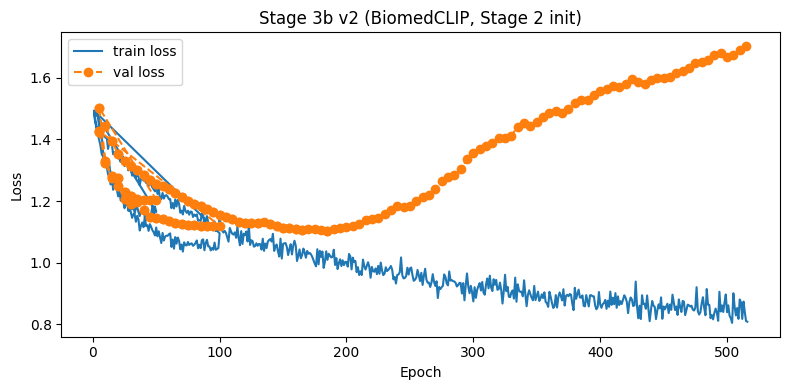

学習曲線を保存: training_curves_v2.png


In [16]:
import re, os
import matplotlib.pyplot as plt

def parse_log(log_path):
    epochs, losses, val_data = [], [], []
    ep_pat  = re.compile(r'Epoch\s+(\d+)/\d+.*loss=([\d.]+)')
    val_pat = re.compile(r'val_loss=([\d.]+)')
    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            m = ep_pat.search(line)
            if m:
                epochs.append(int(m.group(1)))
                losses.append(float(m.group(2)))
            m2 = val_pat.search(line)
            if m2:
                val_data.append((epochs[-1] if epochs else 0, float(m2.group(1))))
    return {'epochs': epochs, 'losses': losses, 'val': val_data}

fig, ax = plt.subplots(figsize=(8, 4))
log_path = os.path.join(OUT_3B, 'train.log')
if os.path.exists(log_path):
    d = parse_log(log_path)
    ax.plot(d['epochs'], d['losses'], label='train loss')
    if d['val']:
        ve, vl = zip(*d['val'])
        ax.plot(ve, vl, 'o--', label='val loss')
    ax.set_title('Stage 3b v2 (BiomedCLIP, Stage 2 init)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
else:
    ax.set_title('ログなし')

plt.tight_layout()
plt.savefig(os.path.join(PHASE3_DIR, 'training_curves_v2.png'), dpi=120)
plt.show()
print('学習曲線を保存: training_curves_v2.png')

## トラブルシューティング

| 症状 | 原因 | 対処 |
|------|------|------|
| Step 6 で `AssertionError: 次元不一致: 768` | BiomedCLIP モデルバージョン差異 | `cfg_3b['model']['clip_dim'] = 768` に変更して YAML 再生成 |
| `CUDA out of memory` | VRAM 不足 | `batch_size: 2` に変更して YAML 再生成 |
| `ModuleNotFoundError: patchalign3d` | Step 4 のパス設定不足 | Step 4 セルを再実行 |
| BiomedCLIP ダウンロード失敗 | HF Token 未設定 | Colab Secrets に `HF_TOKEN` を設定して再実行 |
| `[Stage3] チェックポイントが見つかりません` | `patchalign3d.pt` がない | Step 7 を再実行 |
| EWC Fisher 計算が遅い | バッチ数が多い | `cfg_3b['loss']['ewc_fisher_batches'] = 20` に変更 |